# Project 4 — Quantization Workload Modeling

This notebook follows the AccelForge workflow:
1. define workload YAML (`iteration_space_shape`, `bits_per_value`, `einsums`)
2. load with `af.Spec.from_yaml(...)`
3. run `auto_map()` to find optimal mappings via FFM mapper
4. compare baseline (FP16) vs quantized (W4A16, W4A4) configurations

## Tasks

- Study hardware cost of supporting quantization
- Create a compound component to model quantization area/energy
- Pick a workload and augment the spec with einsums that represent quantization

Three configurations are modeled: **Baseline FP16**, **NVFP4 Weight-Only (W4A16)**, and **NVFP4 Full (W4A4)**.

In [2]:
from pathlib import Path
import os
import yaml
import json as _json
import types
import numpy as np

try:
    import accelforge as af
    from accelforge.mapper import Metrics
    AF_AVAILABLE = True
except Exception as e:
    af = None
    AF_AVAILABLE = False
    print("accelforge import failed:", e)
    print("Notebook will still generate workload/mapping YAML files.")
    print("Run evaluation cells in your AccelForge-enabled environment.")


def find_lab_root() -> Path:
    cwd = Path.cwd()
    env_root = os.environ.get("AF_LAB4_ROOT")
    if env_root:
        return Path(env_root).expanduser()
    if (cwd / "project4_m1_quantization_workload.ipynb").exists() or (cwd / "project4_m1").exists():
        return cwd
    nested = cwd / "workspace" / "lab_4"
    if nested.exists():
        return nested
    return cwd


ROOT = find_lab_root()
OUT_DIR = ROOT / "project4_m1"
OUT_DIR.mkdir(exist_ok=True)

ARCH_FILE = OUT_DIR / "arch_template.yaml"
ARCH_PARAMS = dict(
    GLB_SIZE = 524288,
    RF_SIZE  = 1024,
    PE_X     = 8,
    PE_Y     = 8,
    DRAM_BW  = 8,
    GLB_BW   = 32,
)
print(f"Architecture: GLB={ARCH_PARAMS['GLB_SIZE']//8//1024}KB, "
      f"RF={ARCH_PARAMS['RF_SIZE']//8}B/PE, "
      f"PEs={ARCH_PARAMS['PE_X']}x{ARCH_PARAMS['PE_Y']}="
      f"{ARCH_PARAMS['PE_X']*ARCH_PARAMS['PE_Y']}")


def dump_yaml(path: Path, obj: dict):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)


def _extract_breakdown(df, best_idx, einsum_names):
    """Extract per-Einsum energy and latency breakdown from DataFrame columns.

    Returns (e_bk, l_bk, e_compute, e_memory, l_compute, l_memory) where each
    is a dict {einsum_name: value}.  Energy dicts sum contributions; latency
    dicts take the max across components in each category.
    """
    import pandas as pd
    row = df.iloc[best_idx]

    e_bk, e_compute, e_memory = {}, {}, {}
    compute_components = set()
    memory_components = set()
    leak_entries = []

    # --- Pass 1: energy columns — classify components and accumulate energy ---
    for col in df.columns:
        parts = col.split('<SEP>')
        if len(parts) < 3 or parts[0] not in einsum_names or parts[1] != 'energy':
            continue
        einsum = parts[0]
        component = parts[2]
        action = parts[-1]
        val = row[col]
        try:
            fval = float(val)
        except (TypeError, ValueError):
            continue
        if pd.isna(fval):
            continue

        e_bk[einsum] = e_bk.get(einsum, 0) + fval
        if action == 'compute':
            e_compute[einsum] = e_compute.get(einsum, 0) + fval
            compute_components.add(component)
        elif action in ('read', 'write', 'metadata_read', 'metadata_write'):
            e_memory[einsum] = e_memory.get(einsum, 0) + fval
            memory_components.add(component)
        elif action == 'leak':
            leak_entries.append((einsum, component, fval))

    # Attribute leak energy based on component type
    for einsum, component, fval in leak_entries:
        if component in compute_components:
            e_compute[einsum] = e_compute.get(einsum, 0) + fval
        else:
            e_memory[einsum] = e_memory.get(einsum, 0) + fval

    # --- Pass 2: latency columns — classify using component sets from pass 1 ---
    l_bk, l_compute, l_memory = {}, {}, {}
    for col in df.columns:
        parts = col.split('<SEP>')
        if len(parts) < 3 or parts[0] not in einsum_names or parts[1] != 'latency':
            continue
        einsum = parts[0]
        component = parts[2]
        val = row[col]
        try:
            fval = float(val)
        except (TypeError, ValueError):
            continue
        if pd.isna(fval):
            continue

        l_bk[einsum] = max(l_bk.get(einsum, 0), fval)
        if component in compute_components:
            l_compute[einsum] = max(l_compute.get(einsum, 0), fval)
        else:
            l_memory[einsum] = max(l_memory.get(einsum, 0), fval)

    return e_bk, l_bk, e_compute, e_memory, l_compute, l_memory


def _print_breakdown(e_bk, l_bk, einsum_names,
                     e_compute=None, e_memory=None,
                     l_compute=None, l_memory=None):
    """Pretty-print per-Einsum breakdown with compute/memory split."""
    total_e = sum(e_bk.values()) if e_bk else 0
    total_l = sum(l_bk.values()) if l_bk else 0

    # --- Energy table ---
    print(f"\n  {'Einsum':<22s} {'Energy (pJ)':>16s} {'Compute':>16s} {'Memory':>16s}  {'Comp%':>6s}")
    print(f"  {'-'*22} {'-'*16} {'-'*16} {'-'*16}  {'-'*6}")
    for name in einsum_names:
        e  = e_bk.get(name, 0)
        ec = (e_compute or {}).get(name, 0)
        em = (e_memory or {}).get(name, 0)
        pct = ec / e * 100 if e else 0
        print(f"  {name:<22s} {e:>16,.0f} {ec:>16,.0f} {em:>16,.0f}  {pct:>5.1f}%")
    tec = sum((e_compute or {}).values())
    tem = sum((e_memory or {}).values())
    pct = tec / total_e * 100 if total_e else 0
    print(f"  {'-'*22} {'-'*16} {'-'*16} {'-'*16}  {'-'*6}")
    print(f"  {'TOTAL':<22s} {total_e:>16,.0f} {tec:>16,.0f} {tem:>16,.0f}  {pct:>5.1f}%")

    # --- Latency table ---
    print(f"\n  {'Einsum':<22s} {'Latency (cyc)':>16s} {'Compute':>16s} {'Memory':>16s}  {'Bottleneck':>10s}")
    print(f"  {'-'*22} {'-'*16} {'-'*16} {'-'*16}  {'-'*10}")
    for name in einsum_names:
        l  = l_bk.get(name, 0)
        lc = (l_compute or {}).get(name, 0)
        lm = (l_memory or {}).get(name, 0)
        bn = "compute" if lc >= lm else "memory"
        print(f"  {name:<22s} {l:>16,.0f} {lc:>16,.0f} {lm:>16,.0f}  {bn:>10s}")
    tlc = sum((l_compute or {}).values())
    tlm = sum((l_memory or {}).values())
    print(f"  {'-'*22} {'-'*16} {'-'*16} {'-'*16}")
    print(f"  {'TOTAL':<22s} {total_l:>16,.0f} {tlc:>16,.0f} {tlm:>16,.0f}")


def auto_map(workload_file, mapping_out_file):
    """Auto-map workload to architecture using FFM mapper, select min-EDP mapping.
    Saves mapping YAML + breakdown JSON. Prints per-Einsum breakdown."""
    if not AF_AVAILABLE:
        raise RuntimeError("accelforge is unavailable in this kernel.")
    spec = af.Spec.from_yaml(str(ARCH_FILE), str(workload_file),
                             jinja_parse_data=ARCH_PARAMS)
    spec.mapper.metrics = Metrics.LATENCY | Metrics.ENERGY
    all_mappings = spec.map_workload_to_arch()
    df = all_mappings.data
    einsum_names = list(all_mappings.einsum_names)
    print(f"Found {len(df)} Pareto-optimal mappings")

    energy_cols = [c for c in df.columns if 'energy' in c.lower()]
    latency_cols = [c for c in df.columns if 'latency' in c.lower()]
    best_idx = 0
    if energy_cols and latency_cols:
        edp = (df[energy_cols[0]] * df[latency_cols[0]]).values
        best_idx = int(np.argmin(edp))

    energy_val = float(df[energy_cols[0]].values[best_idx]) if energy_cols else None
    latency_val = float(df[latency_cols[0]].values[best_idx]) if latency_cols else None
    print(f"Best mapping (min EDP): index {best_idx}")
    print(f"  Energy:  {energy_val} pJ")
    print(f"  Latency: {latency_val} cycles")

    # Per-Einsum breakdown with compute/memory split
    e_bk, l_bk, e_compute, e_memory, l_compute, l_memory = \
        _extract_breakdown(df, best_idx, einsum_names)
    if e_bk:
        _print_breakdown(e_bk, l_bk, einsum_names,
                         e_compute, e_memory, l_compute, l_memory)

    # Save mapping YAML
    result = all_mappings[best_idx]
    mapping_out_file.write_text(result.mapping().to_yaml())
    print(f"\nSaved mapping -> {mapping_out_file}")

    # Save breakdown JSON (persistent, no re-mapping needed)
    bk_file = mapping_out_file.with_suffix('.breakdown.json')
    bk_data = {
        "energy_total": energy_val,
        "latency_total": latency_val,
        "einsum_names": einsum_names,
        "energy_per_einsum": e_bk,
        "latency_per_einsum": l_bk,
        "energy_compute_per_einsum": e_compute,
        "energy_memory_per_einsum": e_memory,
        "latency_compute_per_einsum": l_compute,
        "latency_memory_per_einsum": l_memory,
    }
    with open(bk_file, 'w') as f:
        _json.dump(bk_data, f, indent=2)
    print(f"Saved breakdown -> {bk_file}")

    return types.SimpleNamespace(
        energy_pj=energy_val,
        latency_cycles=latency_val,
        energy_breakdown=e_bk,
        latency_breakdown=l_bk,
        energy_compute=e_compute,
        energy_memory=e_memory,
        latency_compute=l_compute,
        latency_memory=l_memory,
    )


print("Working directory:", Path.cwd())
print("Lab root:", ROOT)
print("Output directory:", OUT_DIR)
print("Architecture:", ARCH_FILE)

Architecture: GLB=64KB, RF=128B/PE, PEs=8x8=64
Working directory: /home/workspace/workspace/lab_4
Lab root: /home/workspace/workspace/lab_4
Output directory: /home/workspace/workspace/lab_4/project4_m1
Architecture: /home/workspace/workspace/lab_4/project4_m1/arch_template.yaml


## Step 1: Baseline dense GEMM workload

Start from a simple lab-style workload with one einsum.

In [3]:
baseline_workload = {
    "workload": {
        "iteration_space_shape": {
            "m": "0 <= m < 4096",
            "n": "0 <= n < 4096",
            "k": "0 <= k < 4096",
        },
        "bits_per_value": {
            "A": 16,
            "W": 16,
            "Y": 16,
        },
        "einsums": [
            {
                "name": "MatMul",
                "tensor_accesses": [
                    {"name": "A", "projection": ["m", "k"], "density": 1.0},
                    {"name": "W", "projection": ["n", "k"], "density": 1.0},
                    {"name": "Y", "projection": ["m", "n"], "output": True},
                ],
            }
        ],
    }
}

baseline_workload_file = OUT_DIR / "workload_baseline.yaml"
dump_yaml(baseline_workload_file, baseline_workload)
print("Wrote baseline workload:", baseline_workload_file)

Wrote baseline workload: /home/workspace/workspace/lab_4/project4_m1/workload_baseline.yaml


In [4]:
baseline_mapping_file = OUT_DIR / "mapping_baseline.yaml"

if AF_AVAILABLE and ARCH_FILE.exists() and baseline_workload_file.exists():
    baseline_result = auto_map(baseline_workload_file, baseline_mapping_file)
else:
    baseline_result = None
    print("Skipped auto-mapping (accelforge unavailable or files missing).")

Getting energy, latency, and leak power for components running MatMul: 100%|██████████| 1/1 [00:00<00:00, 20.55it/s]
Generating pmapping templates for compute QuantMAC Einsum MatMul: 0it [00:00, ?it/s]
Generating pmapping templates for compute FP4MAC Einsum MatMul: 0it [00:00, ?it/s]
Generating pmapping templates for compute RescaleMAC Einsum MatMul: 0it [00:00, ?it/s]
Generating pmapping templates for compute FP16MAC Einsum MatMul: 256it [00:00, 383.90it/s]
Generating jobs: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


Einsum MatMul has 256 pmapping templates:
	0	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  FP16MAC computes MatMul
	1	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [A in RF] T-n  FP16MAC computes MatMul
	2	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [W in RF] T-m  FP16MAC computes MatMul
	3	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [Y in RF] T-k  FP16MAC computes MatMul
	4	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [A in RF] T-n  [W in RF] T-m  FP16MAC computes MatMul
	5	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [W in RF] T-m  [A in RF] T-n  FP16MAC computes MatMul
	6	[Y in DRAM] [W in DRAM] [A in DRAM] T-k  T-m  T-n  S-Y-n  S-Y-m  S-Y-k  S-X-n  S-X-m  S-X-k  [A in RF] T-n  [Y in RF] T-k  FP16MAC

Grouping pmappings for MatMul: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


MatMul: 6.65e10 total, 0 (1/inf) valid, 7.24e06 (1/9.18e03) evaluated, 4 (1/1.66e10) Pareto-Optimal
Total: 6.65e10 total, 0 (1/inf) valid, 7.24e06 (1/9.18e03) evaluated, 4 (1/1.66e10) Pareto-Optimal


Evaluating chosen mappings in detail: 100%|██████████| 4/4 [00:00<00:00, 11.53it/s]

Found 4 Pareto-optimal mappings
Best mapping (min EDP): index 2
  Energy:  240560111616.0 pJ
  Latency: 1073741824.0 cycles

  Einsum                      Energy (pJ)          Compute           Memory   Comp%
  ---------------------- ---------------- ---------------- ----------------  ------
  MatMul                  240,560,111,616   68,719,476,736  171,840,634,880   28.6%
  ---------------------- ---------------- ---------------- ----------------  ------
  TOTAL                   240,560,111,616   68,719,476,736  171,840,634,880   28.6%

  Einsum                    Latency (cyc)          Compute           Memory  Bottleneck
  ---------------------- ---------------- ---------------- ----------------  ----------
  MatMul                    1,073,741,824    1,073,741,824      805,830,656     compute
  ---------------------- ---------------- ---------------- ----------------
  TOTAL                     1,073,741,824    1,073,741,824      805,830,656

Saved mapping -> /home/workspace/work

## Step 2–6: NVFP4-style weight-only augmentation

We now augment the workload spec with explicit quantization tensors and einsums:
- split `k -> kb, ki` with `ki=16`
- add quantized weights `Wq[n,kb,ki]`
- add block scales `Sw[n,kb]`
- add dequantized weights `Wdq[n,kb,ki]`
- add `DequantW` einsum before the main GEMM
- update GEMM to consume `Wdq`

In [5]:
quant_workload = {
    "workload": {
        "iteration_space_shape": {
            "m": "0 <= m < 4096",
            "n": "0 <= n < 4096",
            "kb": "0 <= kb < 256",
            "ki": "0 <= ki < 16",
        },
        "bits_per_value": {
            "A": 16,
            "Wq": 4,
            "Sw": 16,
            "Wdq": 16,
            "Y": 16,
        },
        "einsums": [
            {
                "name": "DequantW",
                "tensor_accesses": [
                    {"name": "Wq", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Sw", "projection": ["n", "kb"], "density": 1.0},
                    {"name": "Wdq", "projection": ["n", "kb", "ki"], "output": True},
                ],
            },
            {
                "name": "MatMulQ",
                "tensor_accesses": [
                    {"name": "A", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Wdq", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Y", "projection": ["m", "n"], "output": True},
                ],
            },
        ],
    }
}

quant_workload_file = OUT_DIR / "workload_nvfp4_weight_only.yaml"
dump_yaml(quant_workload_file, quant_workload)
print("Wrote quantized workload:", quant_workload_file)

Wrote quantized workload: /home/workspace/workspace/lab_4/project4_m1/workload_nvfp4_weight_only.yaml


## Auto-map with AccelForge

We use `map_workload_to_arch()` (FFM mapper) to automatically find optimal mappings.
The architecture's `enabled` constraints ensure each Einsum uses the correct compute unit:
- `DequantW` → `QuantMAC` (FP16 scale/dequantize)
- `MatMulQ` → `FP16MAC` (FP16 multiply-accumulate)

In [6]:
quant_mapping_file = OUT_DIR / "mapping_nvfp4_weight_only.yaml"

if AF_AVAILABLE and ARCH_FILE.exists() and quant_workload_file.exists():
    quant_result = auto_map(quant_workload_file, quant_mapping_file)
else:
    quant_result = None
    print("Skipped auto-mapping (accelforge unavailable or files missing).")

Getting energy, latency, and leak power for components running MatMulQ: 100%|██████████| 2/2 [00:00<00:00, 67.55it/s]
Generating pmapping templates for compute QuantMAC Einsum MatMulQ: 0it [00:00, ?it/s]]
Generating pmapping templates for compute FP4MAC Einsum MatMulQ: 0it [00:00, ?it/s]0.92it/s]
Generating pmapping templates for compute RescaleMAC Einsum MatMulQ: 0it [00:00, ?it/s]t/s] 
Generating pmapping templates for compute QuantMAC Einsum DequantW: 432it [00:02, 209.77it/s]
Generating pmapping templates for compute FP4MAC Einsum DequantW: 0it [00:00, ?it/s]
Generating pmapping templates for compute RescaleMAC Einsum DequantW: 0it [00:00, ?it/s]/s]
Generating pmapping templates for compute FP16MAC Einsum DequantW: 0it [00:00, ?it/s]
Generating pmapping templates for compute FP16MAC Einsum MatMulQ: 432it [00:01, 255.82it/s]
Generating jobs: 100%|██████████| 2/2 [00:03<00:00,  1.56s/it]


Einsum DequantW has 432 pmapping templates:
	0	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-ki  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  QuantMAC computes DequantW
	1	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  [Sw in RF] T-ki  QuantMAC computes DequantW
	2	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-ki  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  [Wdq in RF] QuantMAC computes DequantW
	3	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-ki  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  [Wq in RF] QuantMAC computes DequantW
	4	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  [Sw in RF] T-ki  [Wdq in RF] QuantMAC computes DequantW
	5	[Wq in DRAM] [Sw in DRAM] T-kb  T-ki  T-n  [Wdq in GLB] T-kb  T-ki  T-n  S-Y-n  S-Y-ki  S-Y-kb  S-X-n  S-X-ki  S-X-kb  [Wdq in RF] [Sw in RF] T-ki  Qua

Grouping pmappings for MatMulQ: 100%|██████████| 12/12 [00:05<00:00,  2.28it/s]


MatMulQ: 6.00e12 total, 0 (1/inf) valid, 4.53e07 (1/1.32e05) evaluated, 2.25e03 (1/2.67e09) Pareto-Optimal
DequantW: 9.79e08 total, 0 (1/inf) valid, 1.52e06 (1/645) evaluated, 779 (1/1.26e06) Pareto-Optimal
Total: 6.00e12 total, 0 (1/inf) valid, 4.68e07 (1/1.28e05) evaluated, 3.03e03 (1/1.98e09) Pareto-Optimal


Compressing pmappings: 100%|██████████| 2/2 [00:00<00:00, 15.04it/s]
Joining pmappings for DequantW <--> MatMulQ (2/2): 100%|██████████| 18/18 [00:00<00:00, 114.88it/s]
Evaluating chosen mappings in detail: 100%|██████████| 3/3 [00:00<00:00, 14.61it/s]

Found 3 Pareto-optimal mappings
Best mapping (min EDP): index 2
  Energy:  240548052992.0 pJ
  Latency: 1074790400.0 cycles

  Einsum                      Energy (pJ)          Compute           Memory   Comp%
  ---------------------- ---------------- ---------------- ----------------  ------
  DequantW                     71,827,456       16,777,216       55,050,240   23.4%
  MatMulQ                 240,476,225,536   68,719,476,736  171,756,748,800   28.6%
  ---------------------- ---------------- ---------------- ----------------  ------
  TOTAL                   240,548,052,992   68,736,253,952  171,811,799,040   28.6%

  Einsum                    Latency (cyc)          Compute           Memory  Bottleneck
  ---------------------- ---------------- ---------------- ----------------  ----------
  DequantW                      1,048,576        1,048,576          262,144     compute
  MatMulQ                   1,073,741,824    1,073,741,824    1,073,741,824     compute
  ----------------

## Full NVFP4 Quantization (W4A4) — Two-Level Scaling

NVIDIA's NVFP4 on Blackwell uses **two-level scaling**:
- **Per-tensor scale** (coarse): One FP32 scalar per entire tensor. `projection: []`.
- **Per-block scale** (fine): One FP8 (E4M3) scale per block of 16 elements along K.

### Quantization (FP16 → FP4):
1. `TensorScaleA`: $S_{ga} = \text{reduce}_{m,k_b,k_i}(|A|)$ — per-tensor scale (scalar)
2. `TensorQuantA`: $A_{scl} = A \times S_{ga}^{-1}$
3. `BlockScaleA`: $S_{ba}[m,k_b] = \text{reduce}_{k_i}(|A_{scl}|)$ — per-block scale
4. `BlockQuantA`: $A_q = A_{scl} \times S_{ba}^{-1}$ — quantize to FP4
5–8. Same for weights

### FP4 × FP4 Compute (FP32 accumulate):
9. `MatMulNVFP4`: $Y_{raw}[m,n,k_b] \mathrel{+}= A_q \times W_q$ — reduce $k_i$

### Rescale (2 inputs per einsum):
10. `RescaleBlockA`: $Y_{tmp} = Y_{raw} \times S_{ba}[m,k_b]$
11. `RescaleBlockW`: $Y_{blk} = Y_{tmp} \times S_{bw}[n,k_b]$
12. `RescaleTensorA`: $Y_{tmp2}[m,n] = \sum_{k_b} Y_{blk} \times S_{ga}$ — reduce $k_b$
13. `RescaleTensorW`: $Y = Y_{tmp2} \times S_{gw}$


In [7]:
nvfp4_full_workload = {
    "workload": {
        "iteration_space_shape": {
            "m": "0 <= m < 4096",
            "n": "0 <= n < 4096",
            "kb": "0 <= kb < 256",
            "ki": "0 <= ki < 16",
        },
        "bits_per_value": {
            # Original full-precision inputs
            "A": 16,         # FP16 activations
            "W": 16,         # FP16 weights
            # Per-TENSOR scales — FP32
            "Sga": 32,       # Global scale for activations [m]
            "Sgw": 32,       # Global scale for weights [n]
            # Tensor-scaled intermediates
            "Ascl": 16,      # Activations after global scaling
            "Wscl": 16,      # Weights after global scaling
            # Per-BLOCK scales — FP8 E4M3
            "Sba": 8,        # Block scale for activations [m, kb]
            "Sbw": 8,        # Block scale for weights [n, kb]
            # Quantized — FP4 E2M1
            "Aq": 4,         # Quantized activations
            "Wq": 4,         # Quantized weights
            # FP32 accumulator
            "Yraw": 32,      # FP4*FP4 partial sums
            "Ytmp": 32,      # After activation block rescale
            "Yblk": 32,      # After weight block rescale
            "Ytmp2": 32,     # After activation tensor rescale
            # Final output
            "Y": 16,         # FP16 after all rescaling
        },
        "einsums": [
            # ===== Activation quantization =====
            {
                "name": "TensorScaleA",
                "tensor_accesses": [
                    {"name": "A", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Sga", "projection": ["m"], "output": True},
                ],
            },
            {
                "name": "TensorQuantA",
                "tensor_accesses": [
                    {"name": "A", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Sga", "projection": ["m"], "density": 1.0},
                    {"name": "Ascl", "projection": ["m", "kb", "ki"], "output": True},
                ],
            },
            {
                "name": "BlockScaleA",
                "tensor_accesses": [
                    {"name": "Ascl", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Sba", "projection": ["m", "kb"], "output": True},
                ],
            },
            {
                "name": "BlockQuantA",
                "tensor_accesses": [
                    {"name": "Ascl", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Sba", "projection": ["m", "kb"], "density": 1.0},
                    {"name": "Aq", "projection": ["m", "kb", "ki"], "output": True},
                ],
            },
            # ===== Weight quantization =====
            {
                "name": "TensorScaleW",
                "tensor_accesses": [
                    {"name": "W", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Sgw", "projection": ["n"], "output": True},
                ],
            },
            {
                "name": "TensorQuantW",
                "tensor_accesses": [
                    {"name": "W", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Sgw", "projection": ["n"], "density": 1.0},
                    {"name": "Wscl", "projection": ["n", "kb", "ki"], "output": True},
                ],
            },
            {
                "name": "BlockScaleW",
                "tensor_accesses": [
                    {"name": "Wscl", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Sbw", "projection": ["n", "kb"], "output": True},
                ],
            },
            {
                "name": "BlockQuantW",
                "tensor_accesses": [
                    {"name": "Wscl", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Sbw", "projection": ["n", "kb"], "density": 1.0},
                    {"name": "Wq", "projection": ["n", "kb", "ki"], "output": True},
                ],
            },
            # ===== FP4 x FP4 MatMul =====
            {
                "name": "MatMulNVFP4",
                "tensor_accesses": [
                    {"name": "Aq", "projection": ["m", "kb", "ki"], "density": 1.0},
                    {"name": "Wq", "projection": ["n", "kb", "ki"], "density": 1.0},
                    {"name": "Yraw", "projection": ["m", "n", "kb"], "output": True},
                ],
            },
            # ===== Rescale output =====
            {
                "name": "RescaleBlockA",
                "tensor_accesses": [
                    {"name": "Yraw", "projection": ["m", "n", "kb"], "density": 1.0},
                    {"name": "Sba", "projection": ["m", "kb"], "density": 1.0},
                    {"name": "Ytmp", "projection": ["m", "n", "kb"], "output": True},
                ],
            },
            {
                "name": "RescaleBlockW",
                "tensor_accesses": [
                    {"name": "Ytmp", "projection": ["m", "n", "kb"], "density": 1.0},
                    {"name": "Sbw", "projection": ["n", "kb"], "density": 1.0},
                    {"name": "Yblk", "projection": ["m", "n", "kb"], "output": True},
                ],
            },
            {
                "name": "RescaleTensorA",
                "tensor_accesses": [
                    {"name": "Yblk", "projection": ["m", "n", "kb"], "density": 1.0},
                    {"name": "Sga", "projection": ["m"], "density": 1.0},
                    {"name": "Ytmp2", "projection": ["m", "n"], "output": True},
                ],
            },
            {
                "name": "RescaleTensorW",
                "tensor_accesses": [
                    {"name": "Ytmp2", "projection": ["m", "n"], "density": 1.0},
                    {"name": "Sgw", "projection": ["n"], "density": 1.0},
                    {"name": "Y", "projection": ["m", "n"], "output": True},
                ],
            },
        ],
    }
}

nvfp4_full_workload_file = OUT_DIR / "workload_nvfp4_full.yaml"
dump_yaml(nvfp4_full_workload_file, nvfp4_full_workload)
print("Wrote full NVFP4 workload:", nvfp4_full_workload_file)

Wrote full NVFP4 workload: /home/workspace/workspace/lab_4/project4_m1/workload_nvfp4_full.yaml


In [8]:
nvfp4_full_mapping_file = OUT_DIR / "mapping_nvfp4_full_auto.yaml"

if AF_AVAILABLE and ARCH_FILE.exists() and nvfp4_full_workload_file.exists():
    nvfp4_full_result = auto_map(nvfp4_full_workload_file, nvfp4_full_mapping_file)
else:
    nvfp4_full_result = None
    print("Skipped auto-mapping (accelforge unavailable or files missing).")

Getting energy, latency, and leak power for components running RescaleTensorW: 100%|██████████| 13/13 [00:00<00:00, 27.89it/s]
Generating pmapping templates for compute QuantMAC Einsum TensorScaleW: 40it [00:00, 167.66it/s]
Generating pmapping templates for compute QuantMAC Einsum TensorScaleA: 40it [00:00, 161.22it/s]
Generating pmapping templates for compute FP4MAC Einsum TensorScaleW: 0it [00:00, ?it/s]61it/s]
Generating pmapping templates for compute FP4MAC Einsum TensorScaleA: 0it [00:00, ?it/s]
Generating pmapping templates for compute QuantMAC Einsum BlockScaleW: 65it [00:00, 177.36it/s]]
Generating pmapping templates for compute RescaleMAC Einsum TensorScaleW: 0it [00:00, ?it/s]
Generating pmapping templates for compute RescaleMAC Einsum TensorScaleA: 0it [00:00, ?it/s]
Generating pmapping templates for compute FP16MAC Einsum TensorScaleA: 0it [00:00, ?it/s]2it/s]
Generating pmapping templates for compute FP16MAC Einsum TensorScaleW: 0it [00:00, ?it/s]
Generating pmapping templ

Einsum TensorScaleA has 40 pmapping templates:
	0	[A in DRAM] T-m  [Sga in GLB] T-kb  T-ki  T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  QuantMAC computes TensorScaleA
	1	[A in DRAM] T-m  [Sga in GLB] T-kb  T-ki  T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  [A in RF] QuantMAC computes TensorScaleA
	2	[A in DRAM] T-m  [Sga in GLB] T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  [Sga in RF] T-kb  T-ki  QuantMAC computes TensorScaleA
	3	[A in DRAM] T-m  [Sga in GLB] T-kb  T-ki  T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  [A in RF] [Sga in RF] T-kb  T-ki  QuantMAC computes TensorScaleA
	4	[A in DRAM] T-m  [Sga in GLB] T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  [Sga in RF] T-kb  T-ki  [A in RF] QuantMAC computes TensorScaleA
	5	[A in DRAM] T-m  [A in GLB] [Sga in GLB] T-kb  T-ki  T-m  S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X-kb  QuantMAC computes TensorScaleA
	6	[A in DRAM] T-m  [Sga in GLB] T-kb  T-ki  T-m  [A in GLB] S-Y-m  S-Y-ki  S-Y-kb  S-X-m  S-X-ki  S-X

Grouping pmappings for RescaleTensorW: 100%|██████████| 4/4 [00:00<00:00, 165.15it/s]


MatMulNVFP4: 2.84e13 total, 131 (1/2.17e11) valid, 2.83e07 (1/1.00e06) evaluated, 7.91e03 (1/3.59e09) Pareto-Optimal
BlockQuantA: 6.64e10 total, 0 (1/inf) valid, 1.22e07 (1/5.46e03) evaluated, 1.07e04 (1/6.24e06) Pareto-Optimal
RescaleTensorA: 1.05e12 total, 5 (1/2.11e11) valid, 1.24e07 (1/8.52e04) evaluated, 8.64e03 (1/1.22e08) Pareto-Optimal
TensorQuantA: 7.20e09 total, 0 (1/inf) valid, 5.05e06 (1/1.42e03) evaluated, 2.40e03 (1/3.00e06) Pareto-Optimal
BlockQuantW: 6.64e10 total, 0 (1/inf) valid, 1.22e07 (1/5.46e03) evaluated, 1.07e04 (1/6.24e06) Pareto-Optimal
RescaleBlockA: 2.23e12 total, 0 (1/inf) valid, 6.66e06 (1/3.34e05) evaluated, 3.58e03 (1/6.23e08) Pareto-Optimal
TensorQuantW: 7.20e09 total, 0 (1/inf) valid, 5.05e06 (1/1.42e03) evaluated, 2.50e03 (1/2.87e06) Pareto-Optimal
RescaleBlockW: 2.23e12 total, 0 (1/inf) valid, 6.34e06 (1/3.51e05) evaluated, 3.58e03 (1/6.23e08) Pareto-Optimal
BlockScaleA: 3.64e08 total, 0 (1/inf) valid, 2.73e05 (1/1.33e03) evaluated, 1.83e03 (1/1.99e0

Compressing pmappings: 100%|██████████| 13/13 [00:02<00:00,  5.18it/s]


Not tracking DRAM because its size is enough for the sum of all reservations (4.35% of the total)


Removing unneeded reservations for RescaleBlockW: 100%|██████████| 35/35 [00:00<00:00, 579.01it/s]
Removing unneeded reservations for RescaleTensorA: 100%|██████████| 50/50 [00:00<00:00, 593.78it/s]
Removing unneeded reservations for RescaleTensorW: 100%|██████████| 12/12 [00:00<00:00, 423.04it/s]
Joining pmappings for TensorScaleA <--> TensorQuantA (2/13): 100%|██████████| 24/24 [00:00<00:00, 326.44it/s]
Joining pmappings for TensorQuantA <--> BlockScaleA (3/13): 100%|██████████| 81/81 [00:00<00:00, 224.89it/s]
Grouping pmappings: 100%|██████████| 9/9 [00:00<00:00, 194.69it/s]
Joining pmappings for BlockScaleA <--> BlockQuantA (4/13): 100%|██████████| 315/315 [00:00<00:00, 412.54it/s]
Grouping pmappings: 100%|██████████| 65/65 [00:00<00:00, 284.71it/s]
Joining pmappings for BlockQuantA <--> TensorScaleW (5/13): 100%|██████████| 23/23 [00:00<00:00, 642.54it/s]
Joining pmappings for TensorScaleW <--> TensorQuantW (6/13): 100%|██████████| 133/133 [00:00<00:00, 512.23it/s]
Joining pmappin

Found 94 Pareto-optimal mappings
Best mapping (min EDP): index 49
  Energy:  239949660160.0 pJ
  Latency: 1752728320.0 cycles

  Einsum                      Energy (pJ)          Compute           Memory   Comp%
  ---------------------- ---------------- ---------------- ----------------  ------
  TensorScaleA                 61,362,176       16,777,216       44,584,960   27.3%
  TensorQuantA                101,974,016       16,777,216       85,196,800   16.5%
  BlockScaleA                  60,030,976       16,777,216       43,253,760   27.9%
  BlockQuantA                  70,516,736       16,777,216       53,739,520   23.8%
  TensorScaleW                 61,362,176       16,777,216       44,584,960   27.3%
  TensorQuantW                101,974,016       16,777,216       85,196,800   16.5%
  BlockScaleW                  60,030,976       16,777,216       43,253,760   27.9%
  BlockQuantW                  70,516,736       16,777,216       53,739,520   23.8%
  MatMulNVFP4              78,168

## Per-Einsum Energy & Latency Breakdown

Evaluate existing mappings (no re-mapping needed) and report per-Einsum breakdown.

In [9]:
# Read breakdown from saved JSON files (no re-mapping needed)
configs = [
    (OUT_DIR / "mapping_baseline.breakdown.json", "Baseline FP16"),
    (OUT_DIR / "mapping_nvfp4_weight_only.breakdown.json", "NVFP4 Weight-Only (W4A16)"),
    (OUT_DIR / "mapping_nvfp4_full_auto.breakdown.json", "NVFP4 Full (W4A4)"),
]

for bk_file, label in configs:
    if bk_file.exists():
        with open(bk_file) as f:
            bk = _json.load(f)
        print(f"\n{'='*90}")
        print(f"  {label}")
        print(f"  Total Energy: {bk['energy_total']:,.0f} pJ | Total Latency: {bk['latency_total']:,.0f} cycles")
        print(f"{'='*90}")
        _print_breakdown(
            bk['energy_per_einsum'], bk['latency_per_einsum'], bk['einsum_names'],
            e_compute=bk.get('energy_compute_per_einsum'),
            e_memory=bk.get('energy_memory_per_einsum'),
            l_compute=bk.get('latency_compute_per_einsum'),
            l_memory=bk.get('latency_memory_per_einsum'),
        )
    else:
        print(f"\n{label}: breakdown not found. Run auto_map() first.")


  Baseline FP16
  Total Energy: 240,560,111,616 pJ | Total Latency: 1,073,741,824 cycles

  Einsum                      Energy (pJ)          Compute           Memory   Comp%
  ---------------------- ---------------- ---------------- ----------------  ------
  MatMul                  240,560,111,616   68,719,476,736  171,840,634,880   28.6%
  ---------------------- ---------------- ---------------- ----------------  ------
  TOTAL                   240,560,111,616   68,719,476,736  171,840,634,880   28.6%

  Einsum                    Latency (cyc)          Compute           Memory  Bottleneck
  ---------------------- ---------------- ---------------- ----------------  ----------
  MatMul                    1,073,741,824    1,073,741,824      805,830,656     compute
  ---------------------- ---------------- ---------------- ----------------
  TOTAL                     1,073,741,824    1,073,741,824      805,830,656

  NVFP4 Weight-Only (W4A16)
  Total Energy: 240,548,052,992 pJ | Total 

## Visualizations

Normalized energy and latency ($\text{quantized} / \text{baseline}$) and absolute comparison, read from breakdown JSON files.

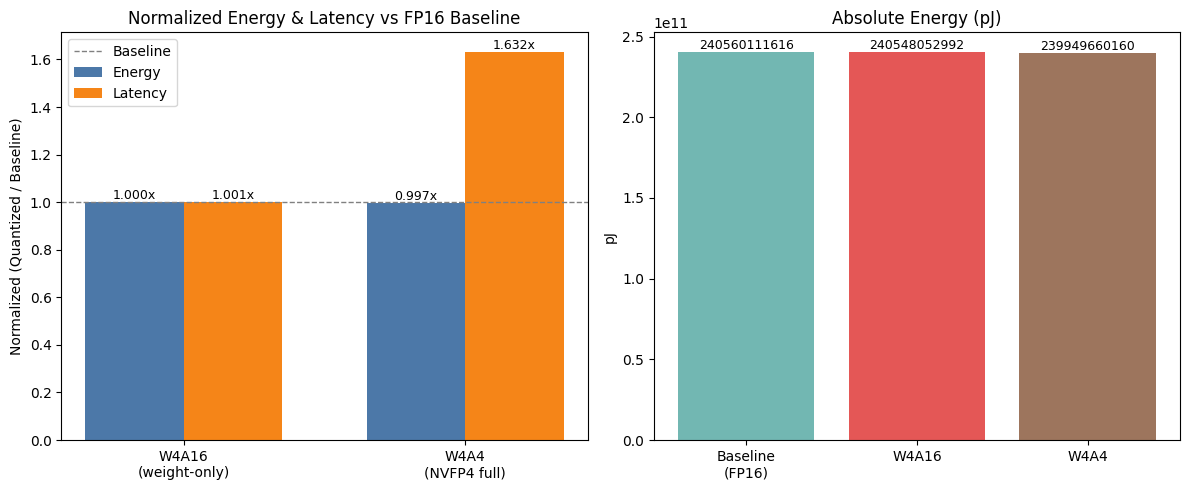

In [10]:
import matplotlib.pyplot as plt

# Load metrics from breakdown JSON files
def load_breakdown(path):
    if path.exists():
        with open(path) as f:
            bk = _json.load(f)
        return bk["energy_total"], bk["latency_total"]
    return None, None

bl_e, bl_l = load_breakdown(OUT_DIR / "mapping_baseline.breakdown.json")
q_e, q_l   = load_breakdown(OUT_DIR / "mapping_nvfp4_weight_only.breakdown.json")
nv_e, nv_l = load_breakdown(OUT_DIR / "mapping_nvfp4_full_auto.breakdown.json")

if all(v is not None for v in [bl_e, bl_l, q_e, q_l, nv_e, nv_l]):
    configs = ["W4A16\n(weight-only)", "W4A4\n(NVFP4 full)"]
    norm_energy  = [q_e / bl_e, nv_e / bl_e]
    norm_latency = [q_l / bl_l, nv_l / bl_l]

    x = np.arange(len(configs))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Normalized bar chart
    ax = axes[0]
    bars1 = ax.bar(x - width/2, norm_energy, width, label="Energy", color="#4C78A8")
    bars2 = ax.bar(x + width/2, norm_latency, width, label="Latency", color="#F58518")
    ax.axhline(1.0, linestyle="--", color="gray", linewidth=1, label="Baseline")
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.set_ylabel("Normalized (Quantized / Baseline)")
    ax.set_title("Normalized Energy & Latency vs FP16 Baseline")
    ax.legend()
    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{bar.get_height():.3f}x", ha="center", va="bottom", fontsize=9)

    # Absolute energy comparison
    ax2 = axes[1]
    abs_labels = ["Baseline\n(FP16)", "W4A16", "W4A4"]
    abs_energy = [bl_e, q_e, nv_e]
    colors = ["#72B7B2", "#E45756", "#9D755D"]
    bars = ax2.bar(abs_labels, abs_energy, color=colors)
    ax2.set_title("Absolute Energy (pJ)")
    ax2.set_ylabel("pJ")
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("Some breakdown files are missing. Run auto_map() for all 3 configs first.")

## Full Proposal + Milestone 3 Sweep

This section runs the new config-driven experiment flow directly from the notebook so you can generate the proposal sweep, milestone-3 architecture sweep, and summary artifacts from one place.

The cells below call the scripts in `project4_m1/` and then load the resulting CSV summaries and figures back into the notebook. If `accelforge` is not available in the kernel environment, the hardware runner will still generate the workload and architecture files, but the hardware CSV rows will remain `generated_only` until you rerun in an AccelForge-enabled environment.


In [ ]:
import csv
import subprocess
import sys
from pathlib import Path

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = None

SWEEP_SCRIPT = OUT_DIR / "run_sweeps.py"
ANALYZE_SCRIPT = OUT_DIR / "analyze_results.py"
MANIFEST_FILE = OUT_DIR / "experiment_manifest.json"
RESULTS_DIR = OUT_DIR / "results"
FIGURES_DIR = OUT_DIR / "figures"

def run_python_script(*args):
    cmd = [sys.executable, *map(str, args)]
    print("$", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=str(ROOT), text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr:
            print(completed.stderr)
        raise RuntimeError(f"Command failed with exit code {completed.returncode}: {.join(cmd)}")
    if completed.stderr:
        print(completed.stderr)
    return completed

def read_csv_rows(path):
    if not path.exists():
        return []
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

print("ROOT:", ROOT)
print("OUT_DIR:", OUT_DIR)
print("Manifest:", MANIFEST_FILE)


In [ ]:
# Run the full proposal + milestone-3 flow.
# Comment out any line below if you want to skip that stage during iterative development.

run_python_script(SWEEP_SCRIPT, "write-manifest", "--output", MANIFEST_FILE)
run_python_script(SWEEP_SCRIPT, "run-accuracy", "--manifest", MANIFEST_FILE)
run_python_script(SWEEP_SCRIPT, "run-hardware", "--manifest", MANIFEST_FILE, "--suite", "proposal")
run_python_script(SWEEP_SCRIPT, "run-hardware", "--manifest", MANIFEST_FILE, "--suite", "milestone3")
run_python_script(SWEEP_SCRIPT, "verify-legacy", "--manifest", MANIFEST_FILE)
run_python_script(ANALYZE_SCRIPT)


## Sweep Summary Tables

This cell loads the generated CSV summaries. If `pandas` is available in the notebook kernel it will render them as dataframes; otherwise it prints a few preview rows.


In [ ]:
summary_files = {
    "accuracy": RESULTS_DIR / "accuracy_summary.csv",
    "proposal_hardware": RESULTS_DIR / "proposal_hardware_summary.csv",
    "milestone3_hardware": RESULTS_DIR / "milestone3_hardware_summary.csv",
    "proposal_combined": RESULTS_DIR / "proposal_combined_summary.csv",
    "best_configs": RESULTS_DIR / "proposal_best_configs.csv",
    "phase_adaptive": RESULTS_DIR / "phase_adaptive_savings.csv",
    "milestone3_saturation": RESULTS_DIR / "milestone3_saturation.csv",
}

for label, path in summary_files.items():
    print(f"\n=== {label}: {path} ===")
    rows = read_csv_rows(path)
    print(f"rows: {len(rows)}")
    if not rows:
        continue
    if pd is not None:
        display(pd.read_csv(path).head(10))
    else:
        for row in rows[:5]:
            print(row)


## Generated Figures

If the analysis script could import `matplotlib`, it writes the Pareto panels and adaptive-savings chart under `project4_m1/figures/`.


In [ ]:
figure_files = [
    FIGURES_DIR / "pareto_panels.png",
    FIGURES_DIR / "phase_adaptive_savings.png",
]

for figure_path in figure_files:
    print(figure_path)
    if not figure_path.exists():
        print("  missing")
        continue
    if Image is not None and display is not None:
        display(Image(filename=str(figure_path)))
    else:
        print("  figure generated")
